<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 4: Automatic Differentiation

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>    
    <li><a href='#gradient' style="color:black;">First Overview of Gradient Computation Using PyTorch</a></li>
    <li><a href='#toy_gradient' style="color:black;">Gradient Computation: Toy Example</a></li> 
    <li><a href='#background_dimensions' style="color:#1B5E20;"><strong>Background:</strong> Tensor Shapes and Batch Dimensions</a></li>  
    <li><a href='#background_gradientdescent' style="color:#1B5E20;"><strong>Background:</strong> Gradient Descent</a></li>  
    <li><a href='#gradientdescent_regression' style="color:black;">Gradient Descent: Regression Example</a></li>    
    <li><a href='#background_polynomialregression' style="color:#1B5E20;"><strong>Background:</strong> Polynomial Regression</a></li>
    <li><a href='#autograd' style="color:black;">Autograd Functionality</a></li>    
    <li><a href='#gradientcontrol' style="color:black;">Stopping Gradient Tracking in PyTorch</a></li>  
    <li><a href='#exercise_learning_rate' style="color:#006064;"><strong>Exercise 1:</strong> Learning Rate</a></li>
    <li><a href='#exercise_gradient_accumulation' style="color:#006064;"><strong>Exercise 2:</strong>  Gradient Accumulation Pitfall</a></li>     
    <li><a href='#exercise_gradient_function2D' style="color:#006064;"><strong>Exercise 3:</strong> Gradient Descent on a 2D Function</a></li>       
</ul> 

<a id='learn'></a>  
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces the foundational concepts of gradient-based optimization and <strong>automatic differentiation</strong> in PyTorch, focusing on how <strong>gradients</strong> are computed and applied during neural network training. It highlights the mechanics and significance of the <code>torch.autograd</code> engine, which automates the computation of derivatives via <strong>computational graphs</strong>. Through a blend of conceptual explanations, manual derivations, and PyTorch-based implementations, the unit provides hands-on insights into <strong>gradient computation</strong> and <strong>gradient descent</strong>, using <strong>polynomial regression</strong> as a guiding example. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Understand the mathematical concept of gradients and their role in optimizing loss functions via gradient descent.</li>
<li>Manually compute gradients in simple examples (e.g., a one-layer linear model) and verify them analytically.</li>
<li>Explore gradient descent as an iterative optimization method, and investigate how learning rates and iteration counts affect convergence.</li>
<li>Apply gradient descent to polynomial regression as a practical use case for parameter optimization.</li>
<li>Use PyTorch's <code>torch.autograd</code> engine for automatic differentiation with tensors and computational graphs.</li>
<li>Understand the significance of <code>requires_grad</code>, <code>.grad</code>, <code>.grad_fn</code>, and <code>.backward()</code> in PyTorch's gradient pipeline.</li>
<li>Manage gradient updates and reset gradients to prevent accumulation during training iterations.</li>
<li>Compare manual gradient descent with autograd-based optimization to build intuition and confidence in both approaches.</li>
<li>Examine practical issues such as vanishing gradients, learning rate sensitivity, and graph management with <code>torch.no_grad()</code> and <code>.detach()</code>.</li>
</ul>

<p style="color:#E65100;">
The unit includes three hands-on exercises:
</p>
    
<ul style="color:#E65100;">
<li><a href="#exercise_learning_rate">Exercise 1</a>: Explore how learning rate and training duration affect convergence in polynomial regression.</li>
<li><a href="#exercise_gradient_accumulation">Exercise 2</a>: Understand the importance of clearing gradients to prevent accumulation.</li>
<li><a href="#exercise_gradient_function2D">Exercise 3</a>: Visualize gradient descent in a two-dimensional, non-convex landscape.</li>
</ul>

<p style="color:#E65100;">
For additional information, see the official PyTorch tutorial on <a href="https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html" target="_blank">Automatic Differentiation with torch.autograd</a> from the <a href="https://pytorch.org/tutorials/beginner/basics/intro.html" target="_blank">Introduction to PyTorch</a> series.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import torch
from matplotlib import pyplot as plt

# --- Custom utilities (Unit 4) ---
from libpcpt.unit04 import (
    generate_training_pairs,
    plot_training_pairs,
    exercise_learning_rate,
    exercise_gradient_accumulation,
    exercise_gradient_function2D
)

# --- Vectorized figures ---
%config InlineBackend.figure_formats = ['svg']

<a id='gradient'></a>  
## First Overview of Gradient Computation Using PyTorch

This section provides a **first high-level overview** of how gradient computation works in PyTorch. You are **not expected to understand every detail right now**. Instead, this part is meant to introduce some of the key concepts and terminology that will reappear throughout this unit. Think of it as an **initial orientation** that sets the stage&mdash;things will become much clearer as we dive into concrete examples and practical exercises later on.

In deep learning, **gradient descent** is one of the most widely used optimization algorithms for minimizing a model's cost or loss function. At the heart of this method lies the concept of the **gradient**&mdash;a vector composed of the partial derivatives of a multivariate function with respect to each of its input variables. The gradient reveals how the function changes in the vicinity of a given point and indicates the direction of steepest ascent. Therefore, by moving in the opposite direction of the gradient, the function's value decreases most rapidly. This principle forms the core idea of **gradient descent**, which iteratively adjusts parameters to find a local minimum of the loss function. For further explanation, we refer to the <a href="#background_gradientdescent">background textbox about gradient descent</a> below.

Because computing the gradient of a differentiable function is essential for training neural networks, PyTorch provides the differentiation engine called [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html), which performs **automatic gradient computations** for any computational graph. Conceptually, a neural network can be represented as a [**directed acyclic graph**](https://en.wikipedia.org/wiki/Directed_acyclic_graph) (**DAG**):

* The DAG defines the network's **forward pass**.
* The **nodes** are tensors, and the **edges** are operations that produce output tensors from input tensors.
* In the DAG, the **leaves** are the input tensors, and the **roots** are the output tensors.

By tracing back this graph from roots to leaves, `torch.autograd` applies the **chain rule** to compute gradients automatically. Here are some key terms and mechanisms involved:

* To enable differentiation, you must declare which tensors require gradients by setting `requires_grad=True`. These tensors typically include the network's **trainable parameters** (e.g., weights and biases).

* Each tensor has a `.grad_fn` attribute pointing to the function that created it, allowing PyTorch to **trace the computation** backward during gradient calculation.

* Calling `.backward()` on a scalar output tensor triggers `torch.autograd` to compute and **accumulate gradients** in the `.grad` attributes of all involved tensors. This step is also often referred to as **backpropagation**.

* The final computed gradients with respect to the trainable tensors (those with `requires_grad=True`) are stored in their `.grad` fields. For example, if `w` is such a tensor, then `w.grad` contains the gradient of the output with respect to `w`.

If these ideas seem abstract now, they will become clearer through detailed examples and exercises later in the unit.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> The terminology can be a source of confusion, as it is important to make a clear distinction between the <strong>input of a network</strong> and the <strong>input of the DAG</strong>. For example, in a linear neural network, the input of the network is typically represented as a tensor <code>x</code>, whereas the training parameters consist of a weight tensor <code>w</code> and a bias tensor <code>b</code>. Within the DAG, the leaf nodes correspond to the learnable tensors <code>w</code> and <code>b</code>, while the network's input tensor  <code>x</code> is treated as a fixed value when computing gradients.<br/><br/>
</p>

<div style="text-align: center;">
  <img src="data/PCPT_fig_representation_NN_DAG.svg" width="400px" style="display: block; margin: auto;" alt="PCPT_fig_representation_NN_DAG.svg">
</div>
</div>

<a id='toy_gradient'></a>  
## Toy Example: Gradient Computation

To build an intuitive understanding of gradient computation in PyTorch, let us consider a simple **toy example** involving a one-layer linear neural network. This example illustrates how to define trainable parameters, compute predictions, evaluate loss, and perform backpropagation. We consider the following setup:

* The **input** of the network is a tensor `x`, and the **target output** is given by the tensor `y`.  
* The **actual output** of the network is denoted by the tensor `z`, which is computed as a linear transformation of `x`.
* The network has two **trainable parameters**: the weight tensor `w` and the bias tensor `b`. These parameters are updated to minimize a loss function that measures the difference between the network output `z` and the target `y`.

Key points to note:

* The parameters `w` and `b` must be initialized with `requires_grad=True` to enable gradient tracking. This can be done during initialization or later using `w.requires_grad_(True)`.
* Once the computational graph has been built, each tensor involved in a computation stores a reference to the function that created it in its `.grad_fn` attribute. This allows PyTorch to trace the graph backward.
* To compute gradients, we define a **loss function**&mdash;in this case, the **mean squared error** (**MSE**)&mdash;and call `loss.backward()`. This triggers PyTorch's `autograd` engine to compute and store the gradients in the `.grad` attributes of `w` and `b`.

In the code example below, we compute the network output `z` as a function of `w` and `b`, then measure its discrepancy from the target `y` using the MSE loss:

In [2]:
# Input and target
# x has shape [1, 2], corresponding to 1 sample (batch size = 1) with 2 input features
x = torch.tensor([[2., 3.]])
# y has shape [1, 1], representing the target output for the single sample
y = torch.tensor([[3.]])

# Initialize trainable parameters with gradient tracking enabled
# w has shape [2, 1], mapping 2 input features to 1 output
w = torch.ones(2, 1, requires_grad=True)
# b has shape [1, 1], representing the bias term added to the output
b = torch.ones(1, 1, requires_grad=True)

# Compute network output
z = torch.matmul(x, w) + b

# Compute loss as mean squared error (MSE)
loss = torch.square(z - y).mean()

# Print intermediate values
print(f"z: {z}")
print(f"Gradient function for z: {z.grad_fn}")
print(f"loss: {loss}")
print(f"Gradient function for loss: {loss.grad_fn}")

# Compute gradients via backpropagation
loss.backward(retain_graph=True)

# Inspect gradients
# w.grad has shape [2, 1], same as w
print(f"w.grad: {w.grad}")
# b.grad has shape [1, 1], same as b
print(f"b.grad: {b.grad}")

z: tensor([[6.]], grad_fn=<AddBackward0>)
Gradient function for z: <AddBackward0 object at 0x000001B10BF768F0>
loss: 9.0
Gradient function for loss: <MeanBackward0 object at 0x000001B10BF768F0>
w.grad: tensor([[12.],
        [18.]])
b.grad: tensor([[6.]])


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> The <code>.grad</code> attribute is available <strong>only</strong> for <strong>leaf nodes</strong> in the computational graph&mdash;these are tensors that were created directly by the user with <code>requires_grad=True</code> and are not the result of other operations.  
In our example, <code>w</code> and <code>b</code> are leaf nodes, so their gradients can be accessed via <code>w.grad</code> and <code>b.grad</code>.  Intermediate results, such as <code>z</code>, are internal nodes in the graph and do not have accessible gradients (i.e., <code>z.grad</code> is <code>None</code>).
</p>
</div>

<a id='background_dimensions'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Tensor Shapes and Batch Dimensions</h2>

<p style="color:#1B5E20;">
In PyTorch, the shapes of tensors play a crucial role in ensuring correct and efficient computations, especially when using <code>torch.matmul</code> and other linear operations. In supervised learning tasks, it is common to structure data in terms of <strong>batches</strong> of input&ndash;output pairs. Below is a general guideline for tensor shapes in a typical single-layer linear network:
</p>

<ul style="color:#1B5E20;">
  <li><code>x</code>: The <strong>input tensor</strong> has shape <code>[B, N]</code>, where <code>B</code> is the batch size (i.e., number of input samples), and <code>N</code> is the number of input features.</li>
  <li><code>w</code>: The <strong>weight matrix</strong> has shape <code>[M, N]</code>, where <code>M</code> is the number of output dimensions (for example, output neurons).</li>
  <li><code>b</code>: The <strong>bias vector</strong> usually has shape <code>[M]</code> (or equivalently <code>[1, M]</code>). When added to the output, it is automatically expanded to match all rows in the batch (this automatic size adjustment is called <strong>broadcasting</strong>).</li>
  <li><code>z = torch.matmul(x, w.T) + b</code>: The <strong>network output</strong> has shape <code>[B, M]</code>, matching the number of input samples and output dimensions.</li>
  <li><code>y</code>: The <strong>target tensor</strong> has shape <code>[B, M]</code> so that it matches the output <code>z</code> and can be directly compared in loss functions.</li>
</ul>

<p style="color:#1B5E20;">
In the case of a single input sample (that is, <code>B = 1</code>), <code>x</code> must still be a 2D tensor of shape <code>[1, N]</code> rather than <code>[N]</code>. This preserves consistency with batch-based computation and avoids shape mismatches in matrix operations. This tensor shape convention allows the same model architecture to scale naturally from single-example inference to efficient batch training.
</p>
</div>

We can confirm this outcome by manually calculating the network output `z` and the gradient of `loss` with respect to `w` and `b`. For our example, the tensor `z` is simply a real number denoted by $z$. By abuse of notation, we treat $z$ as a function $z= z(w_0,w_1,b)$, which depends on the parameters $w_0$, $w_1$, and $b$.

$$z = z(w_0,w_1,b) = x_0 \cdot w_0 + x_1 \cdot w_1 + b = 2\cdot 1 +   3\cdot 1 + 1 = 6$$

For a given target value $y=3$, the loss function is given by 

$$\mathcal{L}(z) = (z-y)^2 = 9$$

The gradient of the loss function $\mathcal{L}$ with respect to the parameters $w_0$, $w_1$ and $b$ are obtained using the chain rule:

\begin{eqnarray}
\frac{\partial\mathcal{L}}{\partial w_0}  
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial w_0} 
= 2\cdot (z-y) \cdot x_0 = 2\cdot 3 \cdot 2 = 12 \\
\frac{\partial\mathcal{L}}{\partial w_1}
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial w_1} 
= 2\cdot (z-y) \cdot x_1 = 2\cdot 3 \cdot 3 = 18 \\
\frac{\partial\mathcal{L}}{\partial b}
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial b}
= 2\cdot (z-y) \cdot 1 = 2\cdot 3 = 6
\end{eqnarray}

Thus, the gradient $\nabla{\mathcal{L}}$ at $(w_0,w_1,b)$ is given by
$$
\nabla{\mathcal{L}}(w_0,w_1,b) = (12,18,6)^\top
$$

<a id='background_gradientdescent'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Gradient Descent</h2>

<p style="color:#1B5E20;">
Gradient descent is a widely used optimization algorithm for finding a local minimum of a differentiable function. It plays a central role in many machine learning applications, where the goal is to minimize a loss or cost function that quantifies prediction error. Let us consider a real-valued function
$$
    \varphi:\mathbb{R}^D \to \mathbb{R}
$$
that depends on $D$ variables, denoted by $u_1, \ldots, u_D$. If $\varphi$ is differentiable, one can compute the <strong>partial derivative</strong> $\frac{\partial \varphi}{\partial u_d}$ with respect to each variable $u_d$, while keeping the others fixed. Collecting all partial derivatives, we obtain the <strong>gradient</strong> at a point $\mathbf{p} \in \mathbb{R}^D$:
$$
    \nabla \varphi(\mathbf{p}) := 
    \left( \frac{\partial \varphi}{\partial u_1}(\mathbf{p}), \ldots, 
           \frac{\partial \varphi}{\partial u_D}(\mathbf{p}) \right)^\top.
$$
The gradient points in the direction of the steepest increase of $\varphi$. To reduce the function value, we move in the opposite direction, that is, along the <strong>negative gradient</strong>. This leads to the following update rule:
$$
    \mathbf{p}' := \mathbf{p} - \gamma \cdot \nabla \varphi(\mathbf{p}),
$$
where $\gamma > 0$ is a <strong>step size</strong> (also called the <strong>learning rate</strong>). For a sufficiently small step size, this move leads to a decrease in the function value, i.e., $\varphi(\mathbf{p}') \leq \varphi(\mathbf{p})$. Based on this principle, <strong>gradient descent</strong> seeks a local minimum of $\varphi$ by iteratively applying the update:
$$
    \mathbf{p}^{(t+1)} := \mathbf{p}^{(t)} - \gamma^{(t)} \cdot \nabla \varphi(\mathbf{p}^{(t)}),
$$
starting from an initial guess $\mathbf{p}^{(0)} \in \mathbb{R}^D$. The parameter $\gamma^{(t)}$ may vary with each iteration. Under suitable conditions, this produces a sequence with non-increasing function values:
$$
    \varphi(\mathbf{p}^{(0)}) \geq \varphi(\mathbf{p}^{(1)}) \geq \varphi(\mathbf{p}^{(2)}) \geq \ldots
$$
Eventually, the sequence of points $\mathbf{p}^{(0)}, \mathbf{p}^{(1)}, \mathbf{p}^{(2)}, \ldots$ approaches a <strong>local minimum</strong>&mdash;a point where the function takes on a value lower than or equal to its value in a small neighborhood. Formally, $\mathbf{p}^*$ is a local minimum if there exists a small $\varepsilon > 0$ such that
$$
    \varphi(\mathbf{p}^*) \leq \varphi(\mathbf{p}) \quad \text{for all } \mathbf{p} \in \mathbb{R}^D \text{ with } \|\mathbf{p} - \mathbf{p}^*\| < \varepsilon.
$$
If the function $\varphi$ is <strong>convex</strong>&mdash;meaning that it curves upward everywhere—then every local minimum is also a <strong>global minimum</strong>. In this case, gradient descent converges to the best possible solution. However, in many machine learning applications, the objective function is non-convex, so gradient descent typically converges to a local (but not necessarily global) minimum.
</p>
</div>

<a id='gradientdescent_regression'></a> 
## Gradient Descent: Regression Example

Let us demonstrate how gradient descent can be used to optimize the parameters of a neural network. To illustrate this process, we consider the task of fitting a second-order polynomial to approximate a predefined target function.

* Let `x` be the input tensor and `y` the target tensor.
* Let `y_pred = a + b * x + c * x**2` be the model output (also called the **prediction**), where `a`, `b`, and `c` are the trainable parameters.
* Let `loss` denote the mean squared error (MSE) between `y_pred` and `y`.
* The goal is to minimize the loss with respect to `a`, `b`, and `c`.

This setup corresponds to a case of **polynomial regression**, which&mdash;unlike general neural networks&mdash;admits a closed-form solution without requiring gradient descent (see the <a href='#background_polynomialregression'>background textbox about polynomial regression</a>  below). However, in the following, we deliberately use an iterative gradient descent approach to highlight the principles of optimization. To begin, we define the input tensor `x` and the corresponding target values `y`, which together form our training data for this simple regression task.

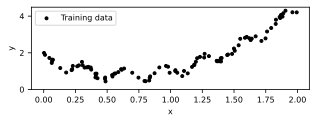

In [3]:
# Generate synthetic training data (input-output pairs)
def generate_training_pairs(num=100):
    torch.manual_seed(0)      # for reproducibility
    x = torch.rand(num) * 2   # random inputs in range [0, 2)   
    # Nonlinear target function with quadratic and oscillatory components + noise
    y = x + 2 * (x - 0.9)**2 + 0.3 * torch.cos(20 * x) + 0.1 * torch.randn(num)
    return x, y

# Generate and plot training data
x, y = generate_training_pairs()
plot_training_pairs(x, y)

Before we apply PyTorch’s `.autograd` engine for automatic gradient computation, we first explore a manual implementation of gradient descent. This hands-on approach deepens our understanding of how optimization works by making explicit each step in the parameter update process. In the code cell below, we construct a simple training loop to minimize the mean squared error between a model prediction and a target function. The model is a second-order polynomial with trainable coefficients `a`, `b`, and `c`. The process includes:

* Initializing the parameters `a`, `b`, and `c` with random values.
* Specifying the learning rate (step size) and number of training iterations.
* In each iteration, we:
  * Compute predictions using the current parameter values.
  * Measure the loss between prediction and target.
  * Manually compute the gradients of the loss with respect to each parameter (see the <a href='#background_polynomialregression'>background textbox about polynomial regression</a> below for details).
  * Adjust the parameters in the direction that reduces the loss the most.

Finally, we visualize the fitted polynomial function alongside the training data to assess how effectively the model has captured the underlying relationship. This hands-on implementation illustrates the core idea of learning through optimization&mdash;adjusting parameters step by step to minimize a loss function.

Iteration 1000 | Loss: 0.2023


Iteration 2000 | Loss: 0.1331


Iteration 3000 | Loss: 0.0954


Iteration 4000 | Loss: 0.0749


Learned parameters: a = 1.4275, b = -1.9894, c = 1.6990


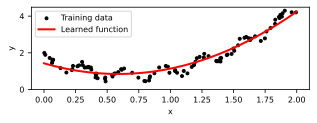

In [4]:
x, y = generate_training_pairs()

# Initialize model parameters (weights) with reproducible random values
torch.manual_seed(0)
a, b, c = torch.randn(3)

# Set learning rate and number of training iterations
learning_rate = 1e-2
num_iterations = 4000

# Training loop
for k in range(1, num_iterations + 1):
    # Forward pass: compute model prediction
    y_pred = a + b * x + c * x**2

    # Compute MSE loss
    loss = torch.square(y_pred - y).mean()
    if k % 1000 == 0:
        print(f"Iteration {k:4d} | Loss: {loss:.4f}", flush=True)

    # Backward pass: manually compute gradients
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.mean()
    grad_b = (grad_y_pred * x).mean()
    grad_c = (grad_y_pred * x**2).mean()

    # Parameter update (gradient descent step)
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c

# Final result
print(f"Learned parameters: a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")
plot_training_pairs(x, y, [a, b, c])

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>  
This basic gradient descent example highlights the core principle of learning by updating parameters. However, its effectiveness is highly sensitive to the chosen <strong>learning rate</strong> and the <strong>initialization</strong> of parameters. In deeper or more complex models, issues such as <strong>vanishing or exploding gradients</strong> can disrupt training. While gradient descent successfully converges in our convex regression example, most real-world problems are <strong>non-convex</strong>. In such cases, the algorithm may get stuck in <strong>local minima</strong> or saddle points. To improve reliability and efficiency, more advanced optimizers&mdash;such as <strong>Stochastic Gradient Descent (SGD)</strong>, <strong>Adam</strong>, and <strong>RMSprop</strong>&mdash;are widely used in practice.
</p>
</div>

<a id='background_polynomialregression'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Polynomial Regression</h2>

<p style="color:#1B5E20;">
<a href="https://en.wikipedia.org/wiki/Polynomial_regression">Polynomial regression</a> is a classical method for modeling the relationship between an input variable and a target output using a polynomial function. Suppose we are given a dataset consisting of $N$ input&ndash;output pairs $(x_n, y_n)$, where each $x_n \in \mathbb{R}$ is an input and $y_n \in \mathbb{R}$ is the corresponding target, for $n \in \{1, \dots, N\}$. We assume that the output can be approximated by a polynomial of degree $D \in \mathbb{N}$ with coefficients $\mathbf{c} = (c_0, c_1, \ldots, c_D)^\top$. The predicted value for a given input $x_n$ is then computed as:
$$
z_n = c_0 + c_1 x_n + c_2 x_n^2 + \cdots + c_D x_n^D.
$$
To fit this model to the data, we define a loss function that measures how well the predictions match the target values. A common choice is the mean squared error (MSE):
$$
\mathcal{L}(\mathbf{c}) = \frac{1}{N} \sum_{n=1}^N (z_n - y_n)^2.
$$
The goal of polynomial regression is to find the coefficient vector $\mathbf{c}$ that minimizes this loss. To illustrate how optimization works, consider computing the partial derivative of the loss with respect to a specific coefficient $c_d$. Since $z_n$ depends on $c_d$ via the term $c_d x_n^d$, we obtain:
$$
\frac{\partial \mathcal{L}}{\partial c_d} = \frac{2}{N} \sum_{n=1}^N (z_n - y_n) \cdot x_n^d.
$$
This expression forms the basis for applying gradient descent to iteratively update the coefficients and reduce the loss.
Alternatively, one can derive the optimal solution analytically using matrix notation. Let $\mathbf{y} = (y_1, y_2, \ldots, y_N)^\top$ denote the target vector, and let $\mathbf{X} \in \mathbb{R}^{N \times (D+1)}$ be the design matrix, where each row consists of the powers of the input $x_n$:
$$
\mathbf{X} = \begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^D \\
1 & x_2 & x_2^2 & \cdots & x_2^D \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_N & x_N^2 & \cdots & x_N^D
\end{bmatrix}.
$$
In this formulation, the predicted outputs can be written as $\hat{\mathbf{y}} = \mathbf{X} \mathbf{c}$. One can show that the optimal coefficient vector $\mathbf{c}^\ast$ minimizing the MSE loss satisfies the <strong>normal equation</strong>
$$
\mathbf{c}^\ast = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}.
$$
This closed-form expression corresponds to the <strong>ordinary least squares</strong> solution of linear regression, obtained by setting the gradient of the MSE loss to zero. Polynomial regression is therefore a special case of linear regression, where the features are polynomial functions of the input variable.
</p>
</div>

Now, we evaluate how well the linear model trained via gradient descent approximates the optimal solution computed analytically. It is worth noting that the training process was limited to 4000 iterations. Since polynomial regression constitutes a convex optimization problem, further improvements in accuracy could likely be achieved by increasing the number of iterations&mdash;assuming the learning rate is appropriately chosen to ensure stable and effective convergence.

Learned parameters from gradient descent:
  a = 1.4275, b = -1.9894, c = 1.6990
  Loss: 0.0749

Closed-form regression parameters:
  a = 1.8195, b = -3.0787, c = 2.2214
  Loss: 0.0503


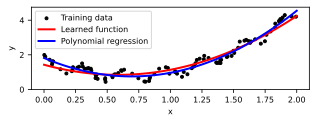

In [5]:
def regression_polynomial_second_order(x: torch.Tensor, y: torch.Tensor):
    """
    Fit a second-order polynomial to data (x, y) using closed-form linear regression.

    Parameters:
        x (torch.Tensor): 1D tensor of input values.
        y (torch.Tensor): 1D tensor of target values.

    Returns:
        a, b, c (float): Coefficients for the polynomial y ≈ a + b*x + c*x^2
        loss (float): Mean squared error (MSE) between predicted and target values.
    """
    # Construct design matrix: each row is [1, x_n, x_n^2]
    X_design = torch.vstack([torch.ones_like(x), x, x**2]).T

    # Solve normal equations: coef = (X^T X)^(-1) X^T y
    coef = torch.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    a, b, c = coef

    # Predict using fitted polynomial
    y_pred = a + b * x + c * x**2

    # Compute mean squared error
    loss = torch.mean((y_pred - y) ** 2)

    return a.item(), b.item(), c.item(), loss.item()


print("Learned parameters from gradient descent:")
print(f"  a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")
print(f"  Loss: {loss:.4f}\n")

a_reg, b_reg, c_reg, loss_regr = regression_polynomial_second_order(x, y)
print("Closed-form regression parameters:")
print(f"  a = {a_reg:.4f}, b = {b_reg:.4f}, c = {c_reg:.4f}")
print(f"  Loss: {loss_regr:.4f}")

# Plot gradient descent result and regression result in one figure
plot_training_pairs(x, y, [a, b, c], [a_reg, b_reg, c_reg]) 

<a id='autograd'></a> 
## Autograd Functionality

We now revisit the previous example using PyTorch's `torch.autograd` engine to perform **automatic gradient computation**. This removes the need to calculate gradients manually and streamlines the training loop. The key differences introduced by the `torch.autograd` approach are as follows:

* The trainable parameters `a`, `b`, and `c` are defined as PyTorch tensors with `requires_grad=True`. This enables PyTorch to track operations and automatically compute gradients.
* Predictions are computed using a second-order polynomial, and the **mean squared error (MSE)** is used as the loss.
* Calling `loss.backward()` triggers PyTorch’s autograd mechanism, which computes the gradients of the loss with respect to `a`, `b`, and `c`. These gradients are stored in `a.grad`, `b.grad`, and `c.grad`, respectively.
* The **parameter update step** is wrapped in a `torch.no_grad()` block to ensure that these updates are not tracked in the computation graph (see <a href='#stopgradient'>gradient tracking control</a> for more details).
* After each update, the gradients are reset to `None`. This is important because PyTorch **accumulates gradients** by default across multiple backward passes.

Using `autograd` not only makes the code more concise and readable but also scales naturally to complex neural networks, where deriving gradients manually would be cumbersome or even impractical.

Iteration 1000 | Loss: 0.1905


Iteration 2000 | Loss: 0.1267


Iteration 3000 | Loss: 0.0919


Iteration 4000 | Loss: 0.0730


Learned parameters: a = 1.4430, b = -2.0325, c = 1.7196


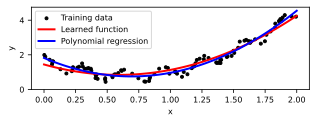

In [6]:
# Import and prepare data
x, y = generate_training_pairs()

# Set data type and reproducibility
dtype = torch.float
torch.manual_seed(1)

# Initialize model parameters (weights) with gradient tracking enabled
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)

# Define training settings
learning_rate = 1e-2
num_iterations = 4000

# Training loop
for k in range(1, num_iterations + 1):
    # Forward pass: compute model output
    y_pred = a + b * x + c * x ** 2

    # Compute loss as mean squared error (MSE)
    loss = (y_pred - y).pow(2).mean()

    # Print progress every 1000 iterations
    if k % 1000 == 0:
        print(f"Iteration {k:4d} | Loss: {loss.item():.4f}", flush=True)

    # Backward pass: compute gradients
    loss.backward()

    # Gradient descent step (wrapped in no_grad to avoid tracking updates)
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad

        # Clear gradients manually to prevent accumulation
        a.grad = None
        b.grad = None
        c.grad = None

# Final result
print(f"Learned parameters: a = {a.item():.4f}, b = {b.item():.4f}, c = {c.item():.4f}")

# Plot gradient descent result and regression result in one figure
plot_training_pairs(x, y, [a.item(), b.item(), c.item()], [a_reg, b_reg, c_reg]) 

<a id='gradientcontrol'></a> 
## Gradient Tracking Control

In PyTorch, **gradient tracking** is crucial during training, as it enables `.backward()` to compute how parameter changes affect a loss function. However, there are situations where tracking gradients is unnecessary or undesirable, such as:

* When performing **inference only** (e.g., using a trained model for predictions).
* When certain parts of a model are **frozen** (i.e., their parameters should not change).
* To **save memory** or **improve speed**.

One way to disable gradient tracking is by placing code inside a with `torch.no_grad():` block. This tells PyTorch not to build the computation graph for operations inside the block.

In [7]:
x = torch.tensor([1,2,3], dtype=torch.float32, requires_grad=True)
z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")
z.backward()
print(f"gradient: {x.grad}")

with torch.no_grad():
    z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")
# In this case, calling z.backward() would result in a runtime error

z: 14.0, requires_grad: True
gradient: tensor([2., 4., 6.])
z: 14.0, requires_grad: False


An alternative way to disable gradient tracking is to use `tensor.detach()`. This method creates a new tensor that shares the same data but is disconnected from the current computation graph, meaning it will not participate in gradient calculations. Detaching tensors is particularly useful when plotting data with `matplotlib`, as it prevents unnecessary gradient tracking during visualization, which could otherwise increase memory usage and computational overhead. In summary:

* Use `torch.no_grad()` when you want to **globally disable gradient tracking**, for example during evaluation or inference with a trained model, to save memory and computation.
* Use `.detach()` when you need to **locally remove a tensor from the computation graph**, for example when visualizing, logging, or reusing intermediate results, while keeping gradient tracking active for the rest of the model's computations.

In [8]:
# Compute a tensor with gradients
x = torch.tensor([1., 2., 3.], requires_grad=True)
z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")  # True

# Detach from the graph
z = z.detach()
print(f"z: {z}, requires_grad: {z.requires_grad}")  # False

z: 14.0, requires_grad: True
z: 14.0, requires_grad: False


<a id='exercise_learning_rate'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Learning Rate</strong><br>

<p style="color:#006064;">
This exercise builds on the basic gradient descent example using PyTorch's <code>torch.autograd</code> engine. The objective is to explore how the choice of <strong>learning rate</strong> and <strong>number of training iterations</strong> affects the model's learning behavior and convergence. Start by implementing a function
</p>

<code>regression_polynomial_second_order_via_gradient(x, y, learning_rate=1e-2, num_iterations=4000)</code>

<p style="color:#006064;">
that follows the <code>torch.autograd</code>-based gradient descent procedure discussed earlier. The function should return the learned parameters <code>a</code>, <code>b</code>, and <code>c</code>, along with the final <code>loss</code>, all as floats. Then, using <code>x, y = training_pairs()</code> as input, run the training with different learning rates:
</p>

<ul style="color:#006064;">
    <li><code>learning_rate = 1e-0</code></li>     
    <li><code>learning_rate = 1e-1</code></li>    
    <li><code>learning_rate = 1e-2</code></li>
    <li><code>learning_rate = 1e-3</code></li>
</ul>

<p style="color:#006064;">
Observe how each learning rate influences the convergence speed and the final loss. You may also experiment with different values for <code>num_iterations</code> to better understand how the number of iterations interacts with the learning rate. Finally, compare the results to the optimal solution obtained from the closed-form polynomial regression. What conclusions can you draw about selecting an appropriate learning rate and number of training iterations in practice?
</p>
</div>

In [9]:
# Your Solution

In [10]:
# Run and show output of the reference solution
exercise_learning_rate()


Changing the learning rate (fixed num_iterations = 4000):


Learning rate 1e+00 | a:     nan, b:     nan, c:     nan, loss:       nan


Learning rate 1e-01 | a:  1.8195, b: -3.0786, c:  2.2214, loss:    0.0503


Learning rate 1e-02 | a:  1.4430, b: -2.0325, c:  1.7196, loss:    0.0730


Learning rate 1e-03 | a:  0.7073, b:  0.0478, c:  0.7156, loss:    0.2522

Changing the number of iterations (fixed learning_rate = 1e-1):
Iterations  100         | a:  0.8828, b: -0.4756, c:  0.9729, loss:    0.1912


...

Iterations 8000         | a:  1.8195, b: -3.0786, c:  2.2214, loss:    0.0503

Changing the number of iterations (fixed learning_rate = 1e-2):
Iterations  100         | a:  0.7115, b:  0.3569, c:  0.5112, loss:    0.3005


Iterations 2000         | a:  1.1279, b: -1.1572, c:  1.2998, loss:    0.1267


Iterations 4000         | a:  1.4430, b: -2.0325, c:  1.7196, loss:    0.0730


Iterations 6000         | a:  1.6145, b: -2.5091, c:  1.9482, loss:    0.0570


Iterations 8000         | a:  1.7079, b: -2.7686, c:  2.0727, loss:    0.0523

Closed-form solution    | a:  1.8195, b: -3.0787, c:  2.2214, loss:    0.0503

Observations / Conclusions:
* Very large learning rates (e.g., 1e+0) can cause divergence or instability.
* Moderate rates (e.g., 1e-1) may converge fast but risk overshooting or oscillating.
* Small rates (e.g., 1e-2) often ensure stable and effective convergence.
* Very small rates (e.g., 1e-3) are stable but slow, requiring many iterations.
* Choosing a suitable learning rate balances speed and stability.
* Gradient descent can closely match the closed-form solution if well-tuned.
* Note that what counts as a small or large learning rate depends on the model, data, and optimization
  landscape. For some problems, even 1e-3 may be too high, while for others it may be too low.


<a id='exercise_gradient_accumulation'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Gradient Accumulation Pitfall</strong><br>

<p style="color:#006064;">
This exercise highlights the importance of resetting gradients during iterative training in PyTorch using <code>.grad = None</code>.
</p>

<ul style="color:#006064;">
  <li>Define a simple quadratic loss: <code>loss = (a * x + b - y)**2</code>, where <code>a</code> and <code>b</code> are scalar parameters optimized via gradient descent.</li>
  <li>Use fixed scalar values for the input and target (e.g., <code>x = 1.5</code> and <code>y = 2.5</code>).</li>
  <li>Initialize the trainable parameters with values (e.g., <code>a = 0.5</code>, <code>b = 0.5</code>), and choose a moderate learning rate (e.g., <code>0.1</code>).</li>
  <li>First, implement gradient descent <strong>without clearing gradients</strong> between steps. Observe how accumulated gradients lead to unstable or diverging updates.</li>
  <li>Then, repeat the process <strong>with gradients properly cleared</strong> after each update, resulting in stable and convergent optimization behavior.</li>
</ul>

<p style="color:#006064;">
This side-by-side comparison demonstrates that failing to reset gradients causes incorrect updates due to accumulation, whereas proper gradient handling ensures reliable training dynamics.
</p>
</div>

In [11]:
# Your Solution


Without gradient clearing:
Target function: loss = (a * x + b - y)**2 with x = 1.5, y = 2.5
Step |       Loss |        a |        b |   grad_a |   grad_b
------------------------------------------------------------
   1 |   1.562500 |   0.5000 |   0.5000 |  -3.7500 |  -2.5000
   2 |   0.191406 |   0.8750 |   0.7500 |  -5.0625 |  -3.3750
   3 |   0.434776 |   1.3813 |   1.0875 |  -3.0844 |  -2.0562
   4 |   1.762671 |   1.6897 |   1.2931 |   0.8986 |   0.5991
   5 |   1.283600 |   1.5998 |   1.2332 |   4.2975 |   2.8650
   6 |   0.040740 |   1.1701 |   0.9467 |   4.9030 |   3.2687
   7 |   0.740418 |   0.6798 |   0.6199 |   2.3216 |   1.5477
   8 |   1.859085 |   0.4476 |   0.4651 |  -1.7689 |  -1.1793
   9 |   0.960844 |   0.6245 |   0.5830 |  -4.7096 |  -3.1397
  10 |   0.001614 |   1.0955 |   0.8970 |  -4.5890 |  -3.0593

With gradient clearing:
Target function: loss = (a * x + b - y)**2 with x = 1.5, y = 2.5
Step |       Loss |        a |        b |   grad_a |   grad_b
------------

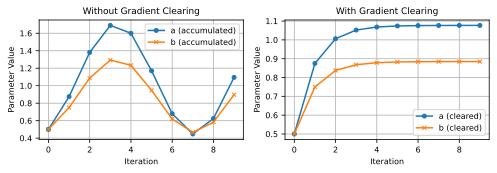

In [12]:
# Run and show output of the reference solution
exercise_gradient_accumulation()

<a id='exercise_gradient_function2D'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Gradient Descent on a 2D Function</strong><br>

<p style="color:#006064;">
The objective of this exercise is to minimize the following non-convex function of two variables using gradient descent:
$$
f(u, v) = (u^2 + v - 11)^2 + (u + v^2 - 7)^2
$$
This function, known as the <strong>Himmelblau function</strong>, features <strong>multiple local minima</strong> and is commonly used to <a href="https://en.wikipedia.org/wiki/Test_functions_for_optimization" target="_blank">benchmark optimization algorithms</a>. Your task is to minimize it using PyTorch's <code>torch.autograd</code> engine by implementing gradient descent step-by-step.
</p>

<ul style="color:#006064;">
  <li>Initialize <code>u</code> and <code>v</code> as scalar tensors with <code>requires_grad=True</code> to enable automatic differentiation.</li>
  <li>Define the loss function as the Himmelblau function using standard PyTorch operations.</li>
  <li>Call <code>loss.backward()</code> to compute gradients with respect to <code>u</code> and <code>v</code>.</li>
  <li>Update the parameters using gradient descent within a <code>torch.no_grad()</code> block to avoid tracking these operations.</li>
  <li>After each step, reset the gradients to <code>None</code> to prevent accumulation across iterations.</li>
</ul>

<p style="color:#006064;">
During training, print the values of <code>u</code>, <code>v</code>, and <code>loss</code> every 100 iterations. Also, store the loss values in a list for further analysis. After training, plot the loss as a function of the iteration number to visualize convergence.
</p>

<br>
<strong style="color:#006064;">Experimentation and Discussion:</strong>
<ul style="color:#006064;">
    <li><strong>Vary the initialization:</strong> Try different starting values for <code>u</code> and <code>v</code>. Observe how the initialization affects convergence and which local minimum is reached. Since the Himmelblau function has multiple local minima, different initializations can lead to different solutions.</li>
    <li><strong>Adjust the learning rate:</strong> Experiment with a range of learning rates. What happens when the learning rate is too small or too large? Analyze how this choice impacts convergence speed, stability, and the final outcome.</li>
    <li><strong>Explore stopping criteria:</strong> Instead of relying solely on a fixed number of iterations, try conditions such as a negligible change in loss.</li>
</ul>

<br>
<p style="color:#006064;">
<strong>Visualization (Optional):</strong><br>
To better understand the behavior of the optimizer, visualize the optimization trajectory by evaluating the Himmelblau function on a 2D grid and plotting it as a heatmap using <code>imshow</code>. Overlay the recorded <code>(u,v)</code> values from training using <code>plt.plot</code>. Mark the starting and ending points using distinct markers (e.g., a white <code>'o'</code> for the start and a red <code>'x'</code> for the end).
</p>
</div>

In [13]:
# Your Solution

Initialized at: u = 1.0, v = 1.0, learning rate = 0.0005
Step  100 | u = 2.8298, v = 2.0261, loss = 0.938195
Step  200 | u = 2.9880, v = 2.0220, loss = 0.008313
Step  300 | u = 2.9974, v = 2.0062, loss = 0.000588
Final: u = 2.9974, v = 2.0061, final loss = 0.000588


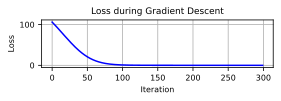

Initialized at: u = -1.0, v = -1.0, learning rate = 0.0005
Step  100 | u = -3.1413, v = -2.1422, loss = 41.550198
Step  200 | u = -3.7448, v = -3.2243, loss = 0.161758
Step  300 | u = -3.7783, v = -3.2816, loss = 0.000130
Final: u = -3.7783, v = -3.2816, final loss = 0.000130


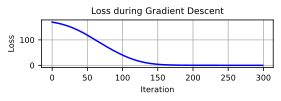

Initialized at: u = -1.0, v = 1.0, learning rate = 0.0005, loss_tol = 0.0001
Step  100 | u = -2.4022, v = 2.9422, loss = 5.786583
Step  200 | u = -2.7859, v = 3.1270, loss = 0.012538
Stopping early at step 233: loss change = 0.000098 < loss_tol = 0.0001
Final: u = -2.7986, v = 3.1301, final loss = 0.001436


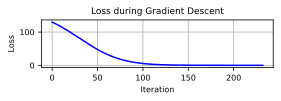

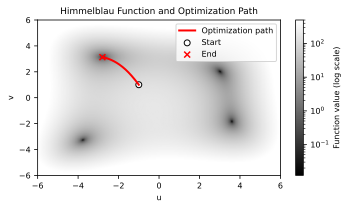

In [14]:
# Run and show output of the reference solution
exercise_gradient_function2D()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>